# Exciton Dimer
## Lindblad Evolution 

In [17]:
#librerie
import numpy as np
from scipy.linalg import expm
import matplotlib.pyplot as plt
from qutip import *
from IPython.display import Image, display, Math

In [18]:
#funzione per plottare in LaTex delle matrici
def array_to_latex(array, real = False, array_name = None):
    array = array.real if real else array
    matrix = ''
    for row in array:
        try:
            for number in row:
                matrix += f'{number}&'
        except TypeError:
            matrix += f'{row}&'
        matrix = matrix[:-1] + r'\\'
    if array_name != None:
        display(Math(array_name+r' = \begin{bmatrix}'+matrix+r'\end{bmatrix}'))
    else:
        display(Math(r'\begin{bmatrix}'+matrix+r'\end{bmatrix}'))

In [19]:
 def Liouvillian(H: np.ndarray,
                gamma_k: list,
                L_k: list):
    I = np.eye(H.shape[0])  #creo matrice identità delle diemnsioni adatte
    super_L = -1.j * (np.kron(I, H) - np.kron(H.T, I))  #Dissipatore di Lindblad
    for k in range(len(gamma_k)):
        super_L += gamma_k[k] * (np.kron(np.conj(L_k[k]), L_k[k]) - 0.5 * np.kron(I, np.conj(L_k[k]).T @ L_k[k]) - 0.5 * np.kron((np.conj(L_k[k]).T @ L_k[k]).T, I))
    return super_L

In [20]:
def Lindblad_evo(rho, H, gamma_k, L_k, t_list, method="U", vectorized=True):
    """
    Evoluzione della matrice densità secondo l'equazione di Lindblad.
    
    method: "U" -> propagatore expm(super_L * dt) (richiede L_k come array NumPy)
            "diagonal" -> diagonalizzazione del super-operatore (richiede L_k come array NumPy)
            "qutip" -> utilizzo di mesolve di QuTiP (richiede L_k come Qobj)
    vectorized: True/False per scegliere il formato dell'output
    
    Output:
            - se vectorized=True → array (N^2, Nt)
            - se vectorized=False → array (Nt, N, N)
       
    """
    N = H.shape[0]
    dt = t_list[1] - t_list[0]
    
    # ===============================
    #   METODI U E DIAGONAL
    # ===============================
    if method in ["U", "diagonal"]:
        # Converte eventuali Qobj in array NumPy
        L_k_num = [L.full() if hasattr(L, "full") else np.array(L) for L in L_k]
        H_num = H.full() if hasattr(H, "full") else np.array(H)
        rho_num = rho.full() if hasattr(rho, "full") else np.array(rho)
        
        # Costruisco il Lindbladian
        super_L = Liouvillian(H_num, gamma_k, L_k_num)
        
        # Stato iniziale vettorializzato
        rho_vec = rho_num.reshape(N*N)
        
        # Array risultato
        rho_vec_list = np.zeros((N*N, len(t_list)), dtype=complex)
        rho_vec_list[:, 0] = rho_vec
        
        # Propagatore temporale
        if method == "U":
            super_U = expm(super_L * dt)
            
            # Evoluzione
            for i in range(1, len(t_list)):
                rho_vec_list[:, i] = super_U @ rho_vec_list[:, i - 1]
            
            # Output
            if vectorized:
                return rho_vec_list  # (N^2, Nt)
            else:
                return rho_vec_list.T.reshape(len(t_list), N, N)  # (Nt, N, N)
                
        elif method == "diagonal":
            W, V = np.linalg.eig(super_L)
            # Converto esplicitamente a NumPy array
            W = np.array(W)
            V = np.array(V)
            
            U_diag = np.diag(np.exp(W * dt))
            super_U = V @ U_diag @ np.linalg.inv(V)
            
            # Evoluzione
            for i in range(1, len(t_list)):
                rho_vec_list[:, i] = super_U @ rho_vec_list[:, i - 1]
            
            # Output con autovettori e autovalori (sempre NumPy array)
            if vectorized:
                return rho_vec_list, V, W  # (N^2, Nt), (N^2, N^2), (N^2,)
            else:
                return rho_vec_list.T.reshape(len(t_list), N, N), V, W  # (Nt, N, N), (N^2, N^2), (N^2,)
    
    # ===============================
    #   METODO QUTIP
    # ===============================
    elif method == "qutip":
        H_qobj = Qobj(H) if not hasattr(H, "full") else H
        rho_qobj = Qobj(rho) if not hasattr(rho, "full") else rho
        
        # Costruzione dei collapse operators
        c_ops = []
        for g, L in zip(gamma_k, L_k):
            if g != 0:
                L_qobj = L if hasattr(L, "full") else Qobj(L)
                c_ops.append(np.sqrt(g) * L_qobj)
        
        # Risoluzione con mesolve
        result = mesolve(
            H_qobj,
            rho_qobj,
            t_list,
            c_ops=c_ops,
            options={"store_states": True},
        )
        
        # Converto gli stati QuTiP in array NumPy vettorializzati
        rho_vec_list = np.zeros((N*N, len(t_list)), dtype=complex)
        for i, rho_t in enumerate(result.states):
            rho_vec_list[:, i] = rho_t.full().reshape(N*N)
        
        # Output
        if vectorized:
            return rho_vec_list
        else:
            return rho_vec_list.T.reshape(len(t_list), N, N)
    
    else:
        raise ValueError("Scegli 'U', 'diagonal' o 'qutip'.")

### Case of study : Excitonic Dimer
We will study the dynamic rappresented with a Lindblad equation of the densit matrix of an excitonic dimer, focusing only on the two excited states. <br>
We'll use an initial density matrix which only has population in the first site: $ \rho (0)  = \begin{bmatrix}1 & 0 \\ 0 & 0 \\\end{bmatrix} $ <br>
First of all we will focus only on the exciton tranfer between the two dimers, so the Jump Operator has this form: $$ \mathcal{L}_{1\rightarrow2} = \ket{e_2}\bra{e_1} \; ; \; \mathcal{L}_{2\rightarrow1} = \ket{e_1}\bra{e_2} $$ 
So that the Dissipator gives:
$$ \mathcal{L}_{1\rightarrow2}\rho_{11}\mathcal{L}_{1\rightarrow2}^\dagger = \ket{e_2}\bra{e_1}\ket{e_1}\bra{e_1}\ket{e_1}\bra{e_2} = \ket{e_2}\bra{e_2} = \rho_{22} $$  
$$ \frac{1}{2} \mathcal{L}_{1\rightarrow2}^\dagger\mathcal{L}_{1\rightarrow2}\rho_{11} = \frac{1}{2} \ket{e_1}\bra{e_2}\ket{e_2}\bra{e_1}\ket{e_1}\bra{e_1} = \frac{1}{2} \ket{e_1}\bra{e_1} = \frac{1}{2}\rho_{11} $$  
$$ \frac{1}{2} \rho_{11}\mathcal{L}_{1\rightarrow2}^\dagger\mathcal{L}_{1\rightarrow2} = \frac{1}{2} \ket{e_1}\bra{e_1}\ket{e_1}\bra{e_2}\ket{e_2}\bra{e_1} = \frac{1}{2} \ket{e_1}\bra{e_1} = \frac{1}{2}\rho_{11} $$ 
and the same for the evolution of $ \rho_{22} $

In [21]:
#System definition
dt = 0.01; t_list = np.arange(0, 100 + dt, dt)
N = 2 # number of sites
E = 1.5 + np.random.randn(N)*0.1   #random inizialization of the system energies {con energia pari a 1.5 ± numero casuale estratto da distribuzione con media 0 e varianza 0.01}
V = 0.1   # Potenziale di interazione
H_tot = [ [0, 0, 0, 0],
          [0, E[1], V, 0],
          [0, V, E[0], 0],
          [0, 0, 0, E[1]+E[0]] ]
#Hamiltonian
H = np.array ([ [E[1], V],     
                [ V, E[0] ] ] , dtype = complex)

#Density Matrix
rho = np.array([[1.0, 0.0],
                [0.0, 0.0]], dtype=complex)

        
#Jump Oerator
L_k = [sigmap().full(), sigmam().full(), ]
#Rates
gamma_1 = 0.1 ; gamma_2 = 0.1
gamma_k = [gamma_2, gamma_1]

Super_L = Liouvillian(H, gamma_k, L_k)

array_to_latex(H, array_name=r'\mathcal{H}') , array_to_latex(Super_L, array_name=r'\mathcal{L}')

<IPython.core.display.Math object>

<IPython.core.display.Math object>

(None, None)

In [13]:
# Evolution with diagonalization of the Lindbaldian operator
rho_list_diag, V, W = Lindblad_evo(rho, H, gamma_k, L_k, t_list, method="diagonal")

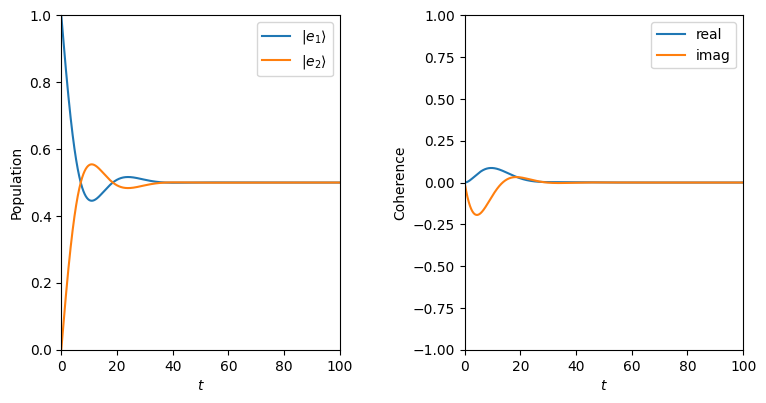

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.plot(t_list, np.real(rho_list_diag[0, :]), label=r'$| e_1 \rangle$')
ax1.plot(t_list, np.real(rho_list_diag[3, :]), label=r'$| e_2 \rangle$')
ax1.set_xlim(0, t_list[-1]); ax1.set_ylim(0, 1); ax1.set_xlabel(r'$t$'); ax1.set_ylabel('Population'); ax1.legend()
ax2.plot(t_list, np.real(rho_list_diag[1, :]), label='real')
ax2.plot(t_list, np.imag(rho_list_diag[1, :]), label='imag')
ax2.set_xlim(0, t_list[-1]); ax2.set_ylim(-1, 1); ax2.set_xlabel(r'$t$'); ax2.set_ylabel('Coherence'); ax2.legend()
fig.tight_layout(); fig.set_size_inches(8, 4); fig.set_dpi(100)

In [15]:
array_to_latex(V)

<IPython.core.display.Math object>

In [16]:
array_to_latex(W)

<IPython.core.display.Math object>

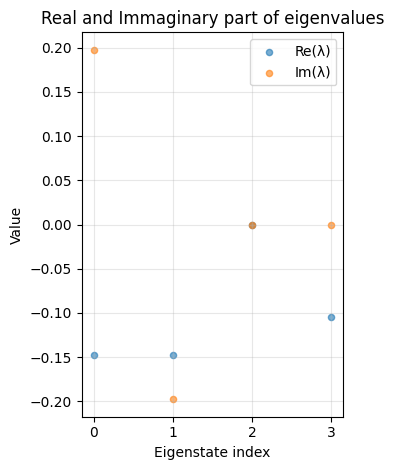

In [11]:
# c) Plot of the eigenvalues with separated real and immaginary part
plt.subplot(1, 2, 2)
idx = np.arange(len(W))
plt.scatter(idx, W.real, alpha=0.6, s=20, label='Re(λ)')
plt.scatter(idx, W.imag, alpha=0.6, s=20, label='Im(λ)')
plt.xlabel('Eigenstate index')
plt.ylabel('Value')
plt.title('Real and Immaginary part of eigenvalues')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Collisional Method
### Quantum Jump / Monte Carlo limit
The goal is to reproduce the Lindbald dynamic seen above using a Collsional Model, that gives us a trajectory of evolution of a single state of the density matrix $ \ket{\Psi_k} $ rappresentig a qubit. By repeting the dynamic several times it's possibile to recrate the Linbald evolution of the density matrix.
Different unravelling of the $ \rho (t) $ can be achieved by using different Collsional Hamiltonian. First we will reproduce the so called "Quantum Jump" or "Monte Carlo" imit, in which essentialy the states stochastically jumps between the states $ \ket{0} $ and $ \ket{1} $ with a small probability to move to $ \ket{1} $. <br> 
The associated Hamiltonian and dynamics is:
$$ \mathcal{H}_{CM} = \mathcal{H}_{exc} \otimes \mathbb{I}^{\otimes N} + \mathcal{H}_{collision} $$ 
$$ = \sum_{j=1}^{N} {\frac{\varepsilon_j}{2} \sigma_{z}^{j} \otimes \mathbb{I}^{\otimes N} } + \sum_{\langle j,j' \rangle} {\frac{V_{j,j'}}{2} \left( \sigma_{x}^{j}\sigma_{x}^{j'} \otimes \mathbb{I}^{\otimes N} + \sigma_{y}^{j}\sigma_{y}^{j'} \otimes \mathbb{I}^{\otimes N} \right)} + \sum_{j=1}^{N}{c_j \sigma_{z}^{j} \otimes \sigma_{x}^{a}} $$
Let's focus on the Interaction Hamiltonian and how it acts on an already enatgled system-ancilla states $ \ket{\Psi} = \ket{\Psi_S} \otimes \ket{0_a} $ <br>
The evolution operator based on $ \mathcal{H}_{collsional} $ is : $$ U_{collsional} = \exp \left(-i c_j \sigma_{z}^{j} \otimes \sigma_{x}^{a} \Delta t\right) = \cos \left(c_j \Delta t \right) \mathbb{I}^j \otimes \mathbb{I}^a - i \sin \left(c_j \Delta t \right) \sigma_{z}^{j} \otimes \sigma_{x}^{a} $$
And applied to $ \ket{\Psi} $ gives:
$$ \begin{align} 
\ket{\Psi'} &= \cos \left(c_j \Delta t \right) \mathbb{I}^j \otimes \mathbb{I}^a \ket{\Psi} - i \sin \left(c_j \Delta t \right) \sigma_{z}^{j} \otimes \sigma_{x}^{a} \ket{\Psi} \\
&= \cos \left(c_j \Delta t \right) \ket{\Psi_S} \otimes \ket{0_a} - i \sin \left(c_j \Delta t \right) \sigma_{z}^{j} \ket{\Psi_S} \otimes \sigma_{x}^{a} \ket{0_a} \\
&= \cos \left(c_j \Delta t \right) \ket{\Psi_S} \otimes \ket{0_a} - i \sin \left(c_j \Delta t \right) \sigma_{z}^{j} \ket{\Psi_S} \otimes \ket{1_a}
\end{align} $$
By measuring the Ancilla's state we can deduce if we had an avoided collision $ \ket{0_a} $ or an occurred collision $ \ket{1_a} $, which imples the application to the system of $ \sigma_{z}^{j} \ket{\Psi_S} $ which introduce a flip in the phase of the interacting site, with a probability of $ \left| {\sin \left(c_j \Delta t \right)} \right|^2  $. <br>
Measuring repeted time s the Ancilla states correspond on racing its states out, so that we could rebuild the density matrix as 
$$ \rho_S = \left| c_0 \right| ^2 \ket{\Psi_{0,S}}\bra{\Psi_{0,S}} + \left| c_1 \right|^2 \ket{\Psi_{1,S}}\bra{\Psi_{1,S}} $$ where $ c_0 \propto \cos \left(c_j \Delta t \right)  $ and $ c_1 \propto \sin \left(c_j \Delta t \right) $ 